In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import random
import itertools
import multiprocess
from math import comb
from functools import partial
from time import time
import matplotlib.gridspec as gridspec
from publib import set_style, fix_style
set_style('article')
random.seed(0)

In [2]:
# Find the neighbours of a given ComboNode derived from the underlying Graph
def NeighbourFinder(Graph, ComboNode): # Output edges connected to this ComboNode
    neighbours = np.empty(shape=(0,len(ComboNode)),dtype=int) # Initialise an empty neighbour np.array
    for idx, i in enumerate(ComboNode):
        ComboNode_list = np.delete(ComboNode,idx) # Get the elements except i
        # Find node i's neighbours in the original graph excluding nodes from ComboNode_list
        i_original_neighbours = np.array([j for j in list(Graph.neighbors(i)) if j not in ComboNode_list])
        # Construct the combinatorial nodes for node i
        i_combo_neighbours = np.array(list(map(lambda x : np.append(ComboNode_list, x), i_original_neighbours)))
        if len(i_combo_neighbours)!=0: # stack the neighbours if it is not none
            i_combo_neighbours.sort(axis=1) # sort the array to create a unique identifier for each combo node
            neighbours = np.vstack((neighbours, i_combo_neighbours))
    # Construct the edges from this ComboNode to its neighbours
    stack = np.repeat(np.array(ComboNode).reshape(1,-1),len(neighbours),axis=0)
    edge_array = np.stack((neighbours, stack),axis=1)
    edges = list(tuple(map(tuple, i)) for i in edge_array) # Convert np.array to list of tuples
    return edges

# Find the ComboSubgraph of size Q centred at a given ComboNode by gradually including multi-hops of neighbours
# Initialise the Combo_Subgraph as nx.Graph() and ComboNode_list as [ComboNode] at beginning 
def ComboSubgraph_Constructor(Graph, ComboSubgraph, ComboNode_list, Q=200, l=1): 
    previous_ComboSubgraph_set = set(ComboSubgraph.nodes())
    for ComboNode in ComboNode_list: # add new neighbours of the previous neighbours to the previous ComboSubgraph
        ComboSubgraph.add_edges_from(NeighbourFinder(Graph, ComboNode))
    new_neighbours = list(set(ComboSubgraph.nodes()) - previous_ComboSubgraph_set)
    print(f"new neighbours at hop {l}: {new_neighbours}")
    if ComboSubgraph.number_of_nodes()<=Q and len(new_neighbours)>0: # do a recursive operation if ComboSubgraph's size < Q
        # Here we set all the neighbours at the current hop as the ComboNode_list for next step
        return ComboSubgraph_Constructor(Graph, ComboSubgraph, new_neighbours, Q, l+1)
    else: # randomly remove a subset of neighbours at the current hop to reach Q 
        nodes_to_remove = random.sample(new_neighbours, 
                                        k=ComboSubgraph.number_of_nodes()-Q)
        ComboSubgraph.remove_nodes_from(nodes_to_remove)
        return ComboSubgraph

# Map the indices of nodes on combinatorial graph to numerical indices
def Index_Mapper(Graph):  # e.g. (2,8,13)-> 3, we need numerical indices for kernel computation
    node_list = [i for i in Graph.nodes()]
    mapping = {old_node: new_idx for new_idx, old_node in enumerate(node_list, start=0)}
    return nx.relabel_nodes(Graph, mapping)

# Construct the entire ComboGraph for k-node combinations given an underlying Graph.
def ComboGraph_Constructor(Graph,k,node=None):
    ComboGraph = nx.Graph() # Initialise the ComboGraph
    total_comb = comb(Graph.number_of_nodes(), k)
    print("Number of ComboNodes:", total_comb)
    if node == None:
        nodes_selfcombo = list(itertools.combinations(list(Graph.nodes()),k)) # All the possible ComboNodes
        # Use multiprocessing to parallel compute each ComboNode's edges
        partial_function = partial(NeighbourFinder, Graph)
        with multiprocess.Pool(8) as pool:
            ComboEdges = pool.map(partial_function, nodes_selfcombo)
    for x in ComboEdges:
        ComboGraph.add_edges_from(x)
    print("Number of ComboEdges:", ComboGraph.number_of_edges())
    return ComboGraph, total_comb

In [3]:
k=2
G = nx.barabasi_albert_graph(n=5,m=2,seed=0)
ComboGraph, total_comb = ComboGraph_Constructor(G,k) # 100 nodes with 3 combination can be a demo

Number of ComboNodes: 10
Number of ComboEdges: 18


In [4]:
ComboGraph_k2, total_comb_k2 = ComboGraph_Constructor(G,2)
ComboGraph_k3, total_comb_k3 = ComboGraph_Constructor(G,3)

pos_original = nx.kamada_kawai_layout(G)
pos_combo2 = nx.kamada_kawai_layout(ComboGraph_k2)
pos_combo3 = nx.kamada_kawai_layout(ComboGraph_k3)

Number of ComboNodes: 10
Number of ComboEdges: 18
Number of ComboNodes: 10
Number of ComboEdges: 18


In [5]:
random.seed(0)
ComboNode = random.sample(list(G.nodes), k)
ComboNode.sort()
ComboNode = tuple(ComboNode)

In [6]:
print("Starting ComboNode:", ComboNode)
Q = total_comb # Q needs to be smaller or equal to the total combinations
ComboSubgraph = ComboSubgraph_Constructor(G, nx.Graph(), [ComboNode], Q=Q)
ComboSubGraph_mapped = Index_Mapper(ComboSubgraph)

Starting ComboNode: (3, 4)
new neighbours at hop 1: [(2, 4), (0, 3), (0, 4), (3, 4)]
new neighbours at hop 2: [(2, 3), (0, 2), (1, 3), (1, 4)]
new neighbours at hop 3: [(0, 1), (1, 2)]
new neighbours at hop 4: []


In [7]:
offset_x = 0.04
offset_y = 0.07
pos_labels = [{},{},{}]

for idx, pos in enumerate([pos_original, pos_combo2, pos_combo3]):
    keys = pos.keys()
    for key in keys:
        x, y = pos[key]
        pos_labels[idx][key] = (x+offset_x, y+offset_y)

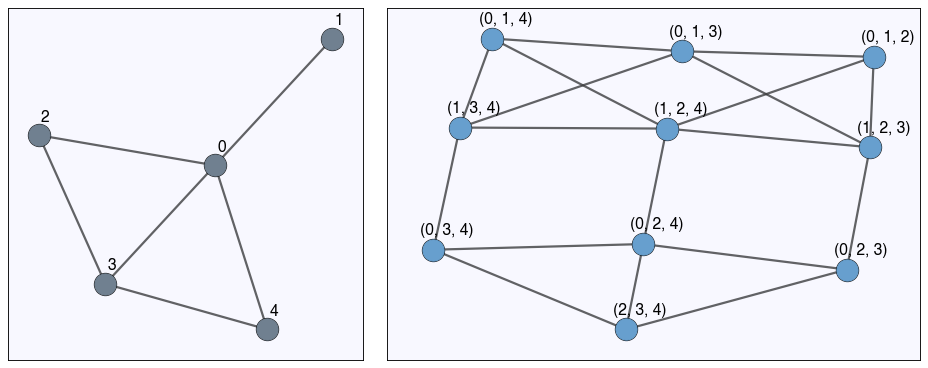

In [8]:
# Draw the ComboGraph using ComboSubgraph_Constructor
node_size = 400
    
fig, ax = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1,1.5]})
nx.draw_networkx(G, pos_original, with_labels=False, node_size=node_size, ax=ax[0],
                 node_color='black', edge_color = '#3b3c3e', width=2, alpha=0.8, )
nc = nx.draw_networkx_nodes(G, pos_original, ax=ax[0], node_size=node_size*0.9, node_color='slategray')
nx.draw_networkx_labels(G, pos_labels[0],verticalalignment='bottom', ax=ax[0],
                        font_size = 14, font_weight="roman")

nx.draw_networkx(ComboGraph_k3, pos_combo3, with_labels=False, node_size=node_size, ax=ax[1],
                 node_color='black', edge_color = '#3b3c3e', width=2, alpha=0.8,)
nc = nx.draw_networkx_nodes(ComboGraph_k3, pos_combo3, ax=ax[1], node_size=node_size*0.9, node_color='#679fce')
nx.draw_networkx_labels(ComboGraph_k3, pos_labels[2], verticalalignment='bottom', ax=ax[1],
                        font_size = 14, font_weight="roman")

ax[0].set_facecolor('ghostwhite')
ax[1].set_facecolor('ghostwhite')
ax[0].grid(False)
ax[1].grid(False)
#ax[0].set_axis_off()
#ax[1].set_axis_off()
plt.tight_layout()

plt.savefig(f"Intro.svg", bbox_inches='tight')

plt.show()

In [9]:
comb(17, 4)

2380

In [10]:
g = nx.barabasi_albert_graph(n=17,m=2,seed=0)
ComboGraph, total_comb = ComboGraph_Constructor(g,4) # 100 nodes with 3 combination can be a demo

Number of ComboNodes: 2380
Number of ComboEdges: 13650


In [11]:
A = nx.adjacency_matrix(g).todense()
ComboNodes = list(ComboGraph.nodes())
ComboNode_Pairs = list(itertools.combinations(ComboNodes,2))

In [12]:
def map_func(idx):
    difference = list(set(ComboNode_Pairs[idx][0]).symmetric_difference(set(ComboNode_Pairs[idx][1])))
    return True if len(difference)==2 and A[difference[0],difference[1]] else False
start = time()
edges_bool = list(map(map_func,range(len(ComboNode_Pairs))))
#print(f"{(time()-start):.1f}s")
#start = time()
edge_array = np.array(ComboNode_Pairs)[edges_bool]
print(f"{(time()-start):.1f}s")

2.3s


In [13]:
edge_array.shape

(13650, 2, 4)

In [14]:
start = time()
edges = list(tuple(map(tuple, i)) for i in edge_array) # Convert np.array to list of tuples
print(f"{(time()-start):.1f}s")

0.0s


In [15]:
start = time()
edges_new = list(map(lambda x: tuple(map(tuple, x.tolist())), edge_array))
print(f"{(time()-start):.1f}s")

0.0s


# Draw the ComboGraph using ComboGraph_Constructor
fig, ax = plt.subplots(1,1, figsize=(10, 8))
nx.draw_networkx(ComboGraph, ax=ax)

In [16]:
# Test if the two methods lead to the same results
nx.is_isomorphic(ComboSubgraph, ComboGraph)

False